# Tugas 5 : Query dengan kalimat

NAMA : Mohammad Iqbal Surya Ramadhan

NIM  : 210411100002

MATA KULIAH : Pencarian dan Penambangan Web - A

mencari 100 dokumen itu (masukkan 1 kalimat, ketemunya dokumen yg mana)

data tfidf ditransofrmasi menjadi sdikit dimensi menggunakan svd
yg diambil v dan sigma (v tdk diambil smua)(Sebagian dri v)
mentransformasi supaya dikit kolom


cosinus similtas (mirip mendekati 1) boleh pke euclidean

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas-PPWA/Hasil_Prepros.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal
0,"Nunggak 8 Bulan, Segini Pajak Ford Mustang Mil...","Kamis, 19 Sep 2024 13:05 WIB",Jakarta - Bareskrim Polri menyita aset senilai...,Otomotif,Jakarta Bareskrim Polri menyita aset senilai ...,jakarta bareskrim polri menyita aset senilai ...,"['jakarta', 'bareskrim', 'polri', 'menyita', '...",jakarta bareskrim polri menyita aset senilai r...
1,Bos Ford Kaget usai Jajal Mobil China: Mereka ...,"Kamis, 19 Sep 2024 12:33 WIB","Jakarta - Chief Executive Officer (CEO) Ford, ...",Otomotif,Jakarta Chief Executive Officer CEO Ford Jim ...,jakarta chief executive officer ceo ford jim ...,"['jakarta', 'chief', 'executive', 'officer', '...",jakarta chief executive officer ceo ford jim f...
2,"Tarif Tol Dalam Kota Naik Jadi Segini, Berlaku...","Kamis, 19 Sep 2024 12:08 WIB",Jakarta - Jasa Marga mengumumkan kenaikan tari...,Otomotif,Jakarta Jasa Marga mengumumkan kenaikan tarif...,jakarta jasa marga mengumumkan kenaikan tarif...,"['jakarta', 'jasa', 'marga', 'mengumumkan', 'k...",jakarta jasa marga mengumumkan kenaikan tarif ...
3,Pak RT Aleix Espargaro Tak Sabar Balapan Terak...,"Kamis, 19 Sep 2024 11:40 WIB","Jakarta - Pebalap Aprilia asal Spanyol, Aleix ...",Otomotif,Jakarta Pebalap Aprilia asal Spanyol Aleix Es...,jakarta pebalap aprilia asal spanyol aleix es...,"['jakarta', 'pebalap', 'aprilia', 'asal', 'spa...",jakarta pebalap aprilia spanyol aleix espargar...
4,Angkot Listrik Bakal Diuji Coba di Jakarta,"Kamis, 19 Sep 2024 11:18 WIB",Jakarta - PT Transportasi Jakarta (TransJakart...,Otomotif,Jakarta PT Transportasi Jakarta TransJakarta ...,jakarta pt transportasi jakarta transjakarta ...,"['jakarta', 'pt', 'transportasi', 'jakarta', '...",jakarta pt transportasi jakarta transjakarta k...


In [9]:
# 2. Preprocessing sederhana (contoh: lowercasing)
berita_preprocessed = [kalimat.lower() for kalimat in df.cleansing]

In [10]:
# 3. TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(berita_preprocessed)

# Mendapatkan fitur (kata-kata) dari TF-IDF
tfidf_features = tfidf_vectorizer.get_feature_names_out()

# Mengonversi matriks TF-IDF menjadi DataFrame agar lebih mudah dibaca
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_features)

# Tampilkan hasil TF-IDF
print("\nHasil TF-IDF dalam bentuk DataFrame:")
print(tfidf_df)



Hasil TF-IDF dalam bentuk DataFrame:
    abang  abdullah  abs  absen        ac  acara  acaraacara  acc  accord  \
0     0.0       0.0  0.0    0.0  0.000000    0.0         0.0  0.0     0.0   
1     0.0       0.0  0.0    0.0  0.000000    0.0         0.0  0.0     0.0   
2     0.0       0.0  0.0    0.0  0.000000    0.0         0.0  0.0     0.0   
3     0.0       0.0  0.0    0.0  0.000000    0.0         0.0  0.0     0.0   
4     0.0       0.0  0.0    0.0  0.107294    0.0         0.0  0.0     0.0   
..    ...       ...  ...    ...       ...    ...         ...  ...     ...   
95    0.0       0.0  0.0    0.0  0.000000    0.0         0.0  0.0     0.0   
96    0.0       0.0  0.0    0.0  0.000000    0.0         0.0  0.0     0.0   
97    0.0       0.0  0.0    0.0  0.000000    0.0         0.0  0.0     0.0   
98    0.0       0.0  0.0    0.0  0.000000    0.0         0.0  0.0     0.0   
99    0.0       0.0  0.0    0.0  0.000000    0.0         0.0  0.0     0.0   

    acdkil  ...  zenix      zero  zhe

Hasil reduksi dimensi dengan SVD:
   Component 1  Component 2  Component 3  Component 4  Component 5  \
0     0.288823    -0.161579     0.159360    -0.102536     0.012820   
1     0.271996    -0.151075     0.039268     0.122868     0.023846   
2     0.208471     0.057110    -0.038819    -0.445492     0.560430   
3     0.258440    -0.053829    -0.294340    -0.057445    -0.225661   
4     0.231934    -0.048862    -0.038915     0.066702     0.016492   

   Component 6  Component 7  Component 8  Component 9  Component 10  
0    -0.004076     0.150679     0.141640    -0.210013      0.240326  
1     0.058164     0.067774     0.141800    -0.121283      0.050399  
2     0.541190     0.009041    -0.060198     0.074419     -0.051876  
3     0.106812     0.009572    -0.163505    -0.005372     -0.114899  
4     0.016621    -0.090944     0.107947    -0.009786     -0.046015  


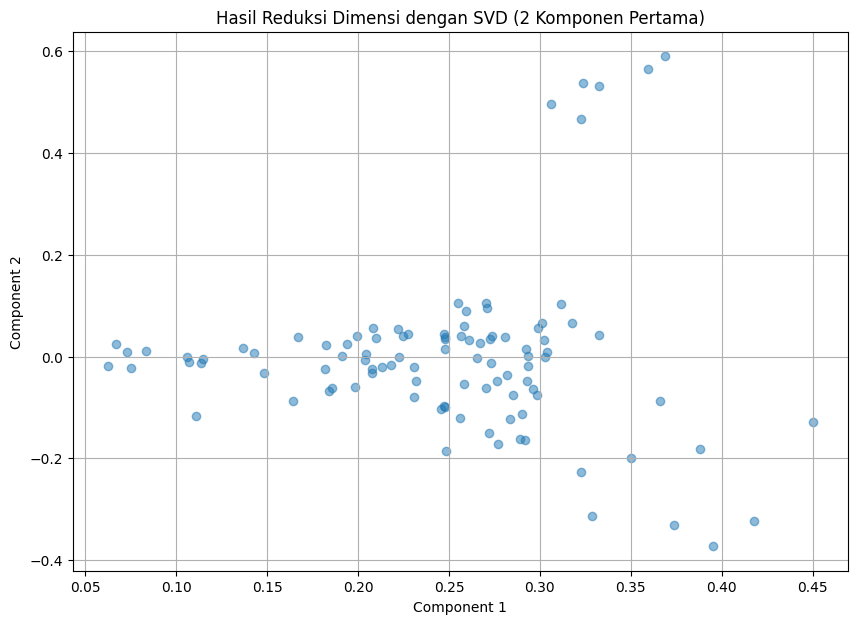

In [12]:
# Menggunakan SVD untuk reduksi dimensi
import matplotlib.pyplot as plt # import matplotlib for visualization
from sklearn.decomposition import TruncatedSVD # Import TruncatedSVD

# Menggunakan SVD untuk reduksi dimensi
n_components = 10  # Jumlah komponen yang ingin digunakan
svd = TruncatedSVD(n_components=n_components)
svd_matrix = svd.fit_transform(tfidf_matrix)

# Mengubah hasil SVD menjadi DataFrame untuk kemudahan
svd_df = pd.DataFrame(svd_matrix, columns=[f'Component {i+1}' for i in range(n_components)])

# Menampilkan hasil
print("Hasil reduksi dimensi dengan SVD:")
print(svd_df.head())  # Menampilkan 5 baris pertama dari hasil SVD

# Visualisasi hasil untuk 2 komponen pertama
plt.figure(figsize=(10, 7))
plt.scatter(svd_df['Component 1'], svd_df['Component 2'], alpha=0.5)
plt.title('Hasil Reduksi Dimensi dengan SVD (2 Komponen Pertama)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid()
plt.show()

In [13]:
import re

# Kalimat query
query = """jakarta sedikit beranggapan orang berbadan kurus bebas risiko kolesterol tinggi dibandingkan orang berbadan gemuk ssudah punya kolesterol tinggi sebenarnya anggapan tersebut benar adanyaspesialis penyakit dr aru ariadno sppdkgeh menjelaskan pernyataan tersebut sepenuhnya tepat mengatidakan sebenarnya banyak faktor membuat kadar kolesterol tubuh seseorang naik pola makan buruk kurangnya olahraga memang menjadi faktor utama kolesterol tinggi faktor seperti genetik seseorang berpengaruh advertisement scroll to continue with content kolesterol hubungannya genetik orang kurus mengalami gangguan kolesterol kata dr aru dihubungi detikcom rabu orang memiliki badan gemuk obesitas memang lebih rentan masalah kolesterol tinggi hanya hipertensi masalah obesitas bisa berdampak kesehatan manusia umum ditangani baik baca sederet gejala kolesterol tinggi bisa muncul priaselain berat badan berlebih kerap dikaitkan pola makan tinggi lemak kurangnya aktivitas fisik mana semakin memperbesar risiko tingginya kolesterol darahketika seseorang mengalami obese bisa menyebabkan sindrom metabolik termasuk diabetes kolesterol tinggi hipertensi ujarnya dr aru mengingatkan kolesterol tinggi paling banyak diakibatkan pola makan buruk jarang berolahraga ini berpengaruh pada semua orang tidak melihat orang tersebut memiliki badan kurus gemuk menurutnya pola hidup sehat menjadi kunci utama pengelolaan kadar kolesterol tubuh jangan lupa menjaga tingkat stres berhenti merokok untuk membantu mencegah masalah kolesterol timbul baca juga sering sakit bagian belakang kepala bisa jadi tanda kolesterol tinggi dokter spesialis saraf stroke bisa dicegah dokter spesialis saraf stroke bisa dicegah avksuc kolesterol tinggi badan kurus gaya hidup sehat sindrom metabolik"""

# Preprocessing: menghapus karakter yang tidak perlu dan merapikan spasi
query_preprocessed = re.sub(r'\s+', ' ', query)  # Menghapus spasi berlebih
query_preprocessed = query_preprocessed.strip()  # Menghapus spasi di awal dan akhir
query_preprocessed = re.sub(r'\n+', ' ', query_preprocessed)  # Menghapus newline
query_preprocessed = re.sub(r'-+', '-', query_preprocessed)  # Mengganti banyak dash menjadi satu

# Mengubah ke huruf kecil
query_preprocessed = query_preprocessed.lower()

# Menampilkan hasil
print("Berita yang sudah dirapikan:")
print(query_preprocessed)


Berita yang sudah dirapikan:
jakarta sedikit beranggapan orang berbadan kurus bebas risiko kolesterol tinggi dibandingkan orang berbadan gemuk ssudah punya kolesterol tinggi sebenarnya anggapan tersebut benar adanyaspesialis penyakit dr aru ariadno sppdkgeh menjelaskan pernyataan tersebut sepenuhnya tepat mengatidakan sebenarnya banyak faktor membuat kadar kolesterol tubuh seseorang naik pola makan buruk kurangnya olahraga memang menjadi faktor utama kolesterol tinggi faktor seperti genetik seseorang berpengaruh advertisement scroll to continue with content kolesterol hubungannya genetik orang kurus mengalami gangguan kolesterol kata dr aru dihubungi detikcom rabu orang memiliki badan gemuk obesitas memang lebih rentan masalah kolesterol tinggi hanya hipertensi masalah obesitas bisa berdampak kesehatan manusia umum ditangani baik baca sederet gejala kolesterol tinggi bisa muncul priaselain berat badan berlebih kerap dikaitkan pola makan tinggi lemak kurangnya aktivitas fisik mana semak

In [14]:
# Transformasi query ke bentuk TF-IDF
query_tfidf = tfidf_vectorizer.transform([query_preprocessed])

# Transformasi TF-IDF ke SVD
query_svd = svd.transform(query_tfidf)

# Mengubah hasil query SVD menjadi DataFrame untuk kemudahan
query_svd_df = pd.DataFrame(query_svd, columns=[f'Component {i+1}' for i in range(n_components)])
# Menampilkan hasil
print("Hasil transformasi query ke SVD:")
print(query_svd_df)

Hasil transformasi query ke SVD:
   Component 1  Component 2  Component 3  Component 4  Component 5  \
0     0.110525     0.003002    -0.025577     0.021044    -0.003255   

   Component 6  Component 7  Component 8  Component 9  Component 10  
0    -0.010442    -0.036171    -0.001775     0.025773      0.006688  


In [17]:
# Import the required function
from sklearn.metrics.pairwise import cosine_similarity

# Menghitung cosine similarity antara query dan setiap berita
similarity_scores = cosine_similarity(query_svd, svd_matrix)

# Menampilkan nilai cosine similarity
print("Nilai Cosine Similarity antara query dan setiap berita:")
print(similarity_scores)

Nilai Cosine Similarity antara query dan setiap berita:
[[0.23431795 0.50392525 0.07525794 0.52440764 0.83381217 0.53180754
  0.16115862 0.77921403 0.85435738 0.50450592 0.43434048 0.87842297
  0.17008989 0.84533558 0.92489272 0.53805371 0.43758062 0.02651346
  0.36004142 0.61814649 0.62386315 0.58157614 0.69350141 0.77142697
  0.32948809 0.48526096 0.56888344 0.34965772 0.73182254 0.30743925
  0.64601562 0.62638615 0.92175318 0.76462997 0.35904103 0.6130384
  0.76174096 0.86385949 0.31399973 0.70120864 0.33136643 0.78909764
  0.83775895 0.79592138 0.28219097 0.78542045 0.37663736 0.49380686
  0.23221917 0.63683738 0.07303506 0.67240308 0.64186854 0.26661958
  0.73126931 0.74337283 0.4353221  0.18370777 0.78817062 0.28760935
  0.84059094 0.33143923 0.76687448 0.76417021 0.77296383 0.7007708
  0.407326   0.81643739 0.09587248 0.82922628 0.90605028 0.73911003
  0.85854522 0.81799612 0.19569107 0.33220652 0.8214174  0.79680992
  0.59416097 0.37782211 0.59557434 0.84937822 0.55565898 0.961

In [20]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np # Import the numpy library

# Mengurutkan indeks berdasarkan skor similarity (descending)
most_relevant_indices = np.argsort(similarity_scores[0])[::-1]

# Memastikan indeks tidak melebihi panjang list berita
num_top_results = 5
top_5_relevant_berita = [(i, df.cleansing[i], similarity_scores[0][i]) for i in most_relevant_indices[:num_top_results] if i < len(df.cleansing)]

# Cetak hasil dengan nilai cosine similarity
print("\nBerita yang paling relevan dengan query beserta nilai cosine similarity:")
for idx, (original_index, berita_text, similarity) in enumerate(top_5_relevant_berita, 1):
    # Hanya menampilkan teks berita tanpa karakter yang tidak diinginkan
    cleaned_text = berita_text.replace("r", "").replace("s", "").replace("a", "").replace("t", "").strip()
    print(f"{idx}. (Nomor Asli: {original_index + 1}) {cleaned_text} - Cosine Similarity: {similarity:.4f}")


Berita yang paling relevan dengan query beserta nilai cosine similarity:
1. (Nomor Asli: 84) Jk  Poduen wdh penyimpnn mknn ikonik beui  Thun Tuppewe encm bngku dn gulung ik Kini peuhn edng mempeipkn pengjun pili ecepny wlupun encn ini mih belum finl dn bi j beubh Melni BBC Rbu  Peiden dn CEO Tuppewe Bnd Copoion Luie Ann Goldmn mengkn bhw meek kn memin izin pengdiln unuk memuli poe penjuln bininy dn ingin peuhn eu beopei elm poe kebngkun belngung Tep ehun yng llu peuhn udh mempeingkn bhw meek mungkin kn bngku keculi jik Tuppewe behil mendpkn pendnn bu dengn cep Tuppewe jug udh beuh unuk mengekn penjuln ke pelnggn yng lebih mud Kmi beencn unuk eu melyni p pelnggn kmi yng behg dengn podukpoduk bekuli inggi yng meek uki dn pecyi elm poe ini uj Luie dikuip di BBC juh lebih di  di minggu ini eelh d lpon bhw meek beencn unuk mengjukn kebngkun Tuppewe elh bejung elm behunhun dlm membendung penuunn penjuln podukny Pemilik Tuppewe Melni di iu emi peuhn Tuppewe pem kli didiikn oleh El Sil Tuppe 